# RPA Model Class

A generic `RPAModel` class for the six SN5.2 networks from Araujo & Liotta (2018).

Each model is defined once — ODE equations written in **SymPy**, base parameter values, and the output variable name. Everything else is automatic:
- Steady-state O* is solved analytically.
- RPA parameters (∂O*/∂k = 0) are identified by symbolic differentiation.
- A `scipy`-compatible ODE is produced via `lambdify`.

The test suite validates the RPA parameter list numerically.

In [60]:
import numpy as np
from scipy.integrate import solve_ivp
from sympy import symbols, solve, simplify, diff, lambdify

In [61]:
class RPAModel:
    """
    RPA ODE model defined symbolically with SymPy.

    Parameters
    ----------
    name        : short label
    state_vars  : ordered list of state-variable name strings
    output_var  : name of the output variable (must appear in state_vars)
    params_base : dict of base values for every parameter, including 'Input'
    equations   : list of sympy expressions — the RHS of dxi/dt in the same
                  order as state_vars, written using symbols whose names match
                  state_vars and params_base keys (all declared positive=True)

    Attributes set automatically
    ----------------------------
    O_star_sym  : sympy expression for the analytic steady-state of output_var
    rpa_params  : list of parameter names with ∂O*/∂k = 0
    """

    def __init__(self, name, state_vars, output_var, params_base, equations):
        self.name        = name
        self.state_vars  = list(state_vars)
        self.output_var  = output_var
        self.output_idx  = self.state_vars.index(output_var)
        self.params_base = dict(params_base)
        self._equations  = list(equations)

        self._sym_state   = [symbols(v, positive=True) for v in state_vars]
        self._param_names = [k for k in params_base if k != 'Input']
        self._sym_params  = [symbols(k, positive=True) for k in self._param_names]
        self._sym_input   = symbols('Input', positive=True)

        # ── 1. analytic steady state ──────────────────────────────────────
        self._ss_dict   = self._solve_ss()
        O_sym           = self._sym_state[self.output_idx]
        self.O_star_sym = simplify(self._ss_dict[O_sym])

        # ── 2. RPA parameters: ∂O*/∂k = 0 ────────────────────────────────
        self.rpa_params = [
            name for name, sym in zip(self._param_names, self._sym_params)
            if diff(self.O_star_sym, sym) == 0
        ]

        # ── 3. lambdify ODE once ──────────────────────────────────────────
        _args       = self._sym_state + self._sym_params + [self._sym_input]
        self._f_lam = lambdify(_args, self._equations, modules='numpy')

    # ── private ───────────────────────────────────────────────────────────────

    def _solve_ss(self):
        sols = solve(self._equations, self._sym_state, dict=True)
        if not sols:
            raise ValueError(f"[{self.name}] No analytic steady-state found.")
        return sols[0]

    # ── public API ────────────────────────────────────────────────────────────

    def get_f(self, rpa_overrides=None):
        """Return f(t, y) → dydt for scipy.integrate.solve_ivp."""
        p     = dict(self.params_base)
        if rpa_overrides:
            p.update(rpa_overrides)
        pvals  = [p[k] for k in self._param_names] + [p['Input']]
        f_lam  = self._f_lam
        def f(t, y):
            return f_lam(*y, *pvals)
        return f

    def _repr_latex_(self):
        from sympy import latex as sym_latex

        # ODE rows — aligned at '='
        ode_rows = r' \\'.join(
            r'\dot{' + sym_latex(sv) + r'} &= ' + sym_latex(eq)
            for sv, eq in zip(self._sym_state, self._equations)
        )

        # Steady-state row
        O_sym   = self._sym_state[self.output_idx]
        ss_row  = sym_latex(O_sym) + r'^{*} &= ' + sym_latex(self.O_star_sym)

        # RPA params row
        rpa_str = r',\;'.join(sym_latex(symbols(p, positive=True))
                              for p in self.rpa_params)
        rpa_row = r'\text{RPA params} &:\; ' + rpa_str

        # Use \begin{aligned} (KaTeX-compatible).
        # Header rows use a leading & so the text sits in the left-aligned column.
        body = (
            r'& \textbf{Case\;' + self.name + r'} \\[4pt]'
            + ode_rows
            + r' \\[6pt]'
            + ss_row
            + r' \\[6pt]'
            + rpa_row
        )
        return r'$$\begin{aligned}' + body + r'\end{aligned}$$'

    def __repr__(self):
        return (f"RPAModel('{self.name}', output='{self.output_var}', "
                f"rpa_params={self.rpa_params})")

## Model definitions (cases a – f)

Each model is fully specified by its **SymPy equations** and **base parameter values**.  
`rpa_params` and `O_star_sym` are derived automatically — no hand-annotation required.

> **Symbol note:** the biochemical signal node named *I* is written as the Python variable `Iv`  
> (holding `Symbol('I', positive=True)`) to avoid shadowing SymPy's imaginary unit.

In [62]:
# ── shared symbols ────────────────────────────────────────────────────────────
# State-variable symbols.  Iv = Symbol('I', positive=True) — the signal node.
Iv, O, O1, O2, O3 = symbols('I  O  O1  O2  O3', positive=True)
B,  C,  X,  X1, X2 = symbols('B  C  X   X1  X2', positive=True)

Input_sym = symbols('Input', positive=True)

# All 18 kinetic-parameter symbols used across all cases
(k1, k2, k3, k4, k5, k6, k7, k8, k9,
 k10, k11, k12, k13, k14, k15, k16, k17, k18) = symbols(
    'k1 k2 k3 k4 k5 k6 k7 k8 k9 k10 k11 k12 k13 k14 k15 k16 k17 k18',
    positive=True)

# ── Case a ────────────────────────────────────────────────────────────────────
# Opposer module (upstream) + Balancer module (downstream)
model_a = RPAModel(
    name='a',
    state_vars=['I', 'O', 'O1', 'C', 'B'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=1.0, k2=0.5, k3=1.0, k4=0.5, k5=0.5, k6=1.0,
                     k7=1.0, k8=0.5, k9=0.5, k10=0.5, k11=0.5, k12=0.5),
    equations=[
        k1*Input_sym - k2*Iv  - k3*O1,
        k4*Iv        + k5*C   - k6*O,
        k7*Iv        - k8,
        k9*O1        - k10*B*C,
        k11*O1       - k12*B,          # PDF has +k12*B (sign typo)
    ]
)

# ── Case b ────────────────────────────────────────────────────────────────────
# Balancer module (upstream) + Opposer module (downstream)
model_b = RPAModel(
    name='b',
    state_vars=['I', 'B', 'X', 'O1', 'O'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=1.0, k2=1.0, k3=1.0, k4=1.0, k5=0.5,
                     k7=1.0, k8=1.0, k9=0.5, k10=1.0, k11=1.0),
    equations=[
        k1*Input_sym - k2*Iv,
        k3*Iv        - k4*B,
        k5*B / O1    - k7*X,
        k8*X         - k9,
        k10*Iv*X     - k11*O*B,
    ]
)

# ── Case c ────────────────────────────────────────────────────────────────────
# Two Opposer modules in series
model_c = RPAModel(
    name='c',
    state_vars=['I', 'O', 'O1', 'X', 'O2'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=1.0, k2=0.5, k3=1.0, k4=0.5, k5=0.5, k6=1.0,
                     k7=1.0, k8=0.5, k9=0.5, k10=0.5, k11=0.5, k12=1.0, k13=0.5),
    equations=[
        k1*Input_sym - k2*Iv  - k3*O1,
        k4*Iv        + k5*X   - k6*O,
        k7*Iv        - k8,
        k9*O1        - k10*X  - k11*O2,
        k12*X        - k13,
    ]
)

# ── Case d ────────────────────────────────────────────────────────────────────
# Single Opposer module with two-node opposing set
model_d = RPAModel(
    name='d',
    state_vars=['I', 'O', 'O1', 'X', 'O2'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=0.5, k2=0.5, k3=0.5, k4=1.0, k5=1.0, k6=1.0,
                     k7=1.0, k8=1.0, k9=0.5, k10=1.0, k11=1.0, k12=0.5),
    equations=[
        k1*Input_sym - k2*Iv  - k3*O1,
        k4*Iv        - k5*O,
        k11*X        - k12,
        k8*O2        - k9*X   - k10*O1,
        k6*O         - k7*X,
    ]
)

# ── Case e ────────────────────────────────────────────────────────────────────
# Opposer module (upstream, two-node set) + Balancer module (downstream)
model_e = RPAModel(
    name='e',
    state_vars=['I', 'O1', 'X', 'O2', 'B', 'C', 'O'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=0.5, k2=1.0, k4=1.0, k5=1.0, k6=1.0, k7=1.0, k8=0.4,
                     k9=1.0, k10=0.5, k11=1.0, k12=1.0, k14=0.5, k15=1.0,
                     k16=0.5, k17=0.5, k18=1.0),
    equations=[
        k1*Input_sym - k2*O1*Iv,
        k4*Iv        - k5*X,
        k6*O1        - k7*O2  - k8*X,
        k9*X         - k10,
        k11*O2       - k12*B,
        k14*O2       - k15*B*C,
        k16*Iv       + k17*C  - k18*O,
    ]
)

# ── Case f ────────────────────────────────────────────────────────────────────
# Opposer module (upstream, two-node set) + Opposer module (downstream, single node)
model_f = RPAModel(
    name='f',
    state_vars=['I', 'O1', 'X1', 'O2', 'X2', 'O3', 'O'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=0.5, k2=0.5, k3=0.5, k4=1.0, k5=1.0, k6=1.0, k7=1.0,
                     k8=1.0, k9=1.0, k10=0.5, k11=1.0, k12=0.5, k13=1.0,
                     k14=1.0, k15=0.5, k16=0.5, k17=0.5, k18=1.0),
    equations=[
        k1*Input_sym - k2*Iv   - k3*O1,
        k4*Iv        - k5*X1,
        k6*O1        - k7*O2   - k8*X1,
        k9*X1        - k10,
        k11*O2       - k12*X2  - k13*O3,
        k14*X2       - k15,
        k16*Iv       + k17*X2  - k18*O,
    ]
)

ALL_MODELS = [model_a, model_b, model_c, model_d, model_e, model_f]
for m in ALL_MODELS:
    print(m)

RPAModel('a', output='O', rpa_params=['k1', 'k2', 'k3'])
RPAModel('b', output='O', rpa_params=['k1', 'k2', 'k5', 'k7'])
RPAModel('c', output='O', rpa_params=['k1', 'k2', 'k3', 'k9', 'k10', 'k11'])
RPAModel('d', output='O', rpa_params=['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10'])
RPAModel('e', output='O', rpa_params=['k1', 'k2', 'k6', 'k7', 'k8'])
RPAModel('f', output='O', rpa_params=['k1', 'k2', 'k3', 'k6', 'k7', 'k8', 'k11', 'k12', 'k13'])


In [63]:
# ── Integral-feedback model ───────────────────────────────────────────────────
# dA/dt = α(μ - B)
# dB/dt = β₁ A - β₂ B
#
# μ ≡ Input (the reference/set-point).
# Steady state: B* = μ = Input  (independent of α, β₁, β₂  →  all are RPA params)

A               = symbols('A',               positive=True)
alpha, beta1, beta2 = symbols('alpha beta1 beta2', positive=True)

model_if = RPAModel(
    name='IF',
    state_vars=['A', 'B'],
    output_var='B',
    params_base=dict(Input=1.0, alpha=1.0, beta1=1.0, beta2=1.0),
    equations=[
        alpha * (Input_sym - B),   # dA/dt = α(μ − B)
        beta1 * A - beta2 * B,     # dB/dt = β₁A − β₂B
    ]
)

display(model_if)

RPAModel('IF', output='B', rpa_params=['alpha', 'beta1', 'beta2'])

In [64]:
from IPython.display import display
for model in ALL_MODELS:
    display(model)

RPAModel('a', output='O', rpa_params=['k1', 'k2', 'k3'])

RPAModel('b', output='O', rpa_params=['k1', 'k2', 'k5', 'k7'])

RPAModel('c', output='O', rpa_params=['k1', 'k2', 'k3', 'k9', 'k10', 'k11'])

RPAModel('d', output='O', rpa_params=['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10'])

RPAModel('e', output='O', rpa_params=['k1', 'k2', 'k6', 'k7', 'k8'])

RPAModel('f', output='O', rpa_params=['k1', 'k2', 'k3', 'k6', 'k7', 'k8', 'k11', 'k12', 'k13'])

## RPA parameter validation

For each model and each declared RPA parameter, we run the ODE twice — at the base value and at `scale × base` — and verify that the output O reaches the same steady state (relative difference < `ss_tol`). `Input` is also tested as the primary RPA check.

In [65]:
def validate_rpa_params(model, scale=2.0, t_end=500, ss_tol=1e-2,
                        rtol=1e-10, atol=1e-12):
    """
    For every declared RPA parameter (plus 'Input'), run the ODE at
    the base value and at scale*base value.  Both runs start from the
    same initial condition y0 = 0.5 * ones and integrate to t_end.
    A test passes when the relative difference in the final O value
    is below ss_tol.

    Returns
    -------
    dict mapping param_name -> {base_val, test_val, O_base, O_scaled,
                                 rel_diff, passed}
    """
    y0   = np.ones(len(model.state_vars)) * 0.5
    kw   = dict(method='Radau', rtol=rtol, atol=atol, dense_output=False)

    sol_base = solve_ivp(model.get_f(), (0, t_end), y0, **kw)
    assert sol_base.success, f"Base integration failed for model {model.name}"
    O_base = sol_base.y[model.output_idx, -1]

    results = {}
    for param in model.rpa_params + ['Input']:
        base_val = model.params_base[param]
        test_val = base_val * scale
        sol = solve_ivp(model.get_f({param: test_val}), (0, t_end), y0, **kw)
        assert sol.success, f"Integration failed for model {model.name}, {param}={test_val}"
        O_test   = sol.y[model.output_idx, -1]
        rel_diff = abs(O_test - O_base) / abs(O_base)
        results[param] = dict(
            base_val = base_val,
            test_val = test_val,
            O_base   = O_base,
            O_scaled = O_test,
            rel_diff = rel_diff,
            passed   = rel_diff < ss_tol,
        )
    return results


def print_results(model, results):
    n_pass = sum(r['passed'] for r in results.values())
    n_total = len(results)
    tag = 'PASS' if n_pass == n_total else 'FAIL'
    print(f"[{tag}] Case {model.name}  ({n_pass}/{n_total} params)")
    for param, r in results.items():
        mark = '✓' if r['passed'] else '✗'
        print(f"  {mark} {param:5s}  base={r['base_val']:.3f} → {r['test_val']:.3f}"
              f"  |  O*= {r['O_base']:.5f}  vs  {r['O_scaled']:.5f}"
              f"  (rel Δ = {r['rel_diff']:.1e})")

In [66]:
for model in ALL_MODELS:
    results = validate_rpa_params(model)
    print_results(model, results)
    print()

[PASS] Case a  (4/4 params)
  ✓ k1     base=1.000 → 2.000  |  O*= 0.75000  vs  0.75000  (rel Δ = 0.0e+00)
  ✓ k2     base=0.500 → 1.000  |  O*= 0.75000  vs  0.75000  (rel Δ = 0.0e+00)
  ✓ k3     base=1.000 → 2.000  |  O*= 0.75000  vs  0.75000  (rel Δ = 1.5e-16)
  ✓ Input  base=1.000 → 2.000  |  O*= 0.75000  vs  0.75000  (rel Δ = 0.0e+00)

[PASS] Case b  (5/5 params)
  ✓ k1     base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 1.1e-16)
  ✓ k2     base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 1.1e-16)
  ✓ k5     base=0.500 → 1.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 1.1e-16)
  ✓ k7     base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 1.1e-16)
  ✓ Input  base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 1.1e-16)

[PASS] Case c  (7/7 params)
  ✓ k1     base=1.000 → 2.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 0.0e+00)
  ✓ k2     base=0.500 → 1.000  |  O*= 0.50000  vs  0.50000  (rel Δ = 0.0e+00)
  ✓ k3     base=1.000 → 2.000  |  O*= 0.50000  vs  0.500

## Resonance Strategy

Parametric resonance control for an RPA model. For each RPA parameter, two variants are created (2× and 0.5× baseline). Both assignments are simulated independently — producing two trajectories per RPA parameter:

- **hard = 2×, soft = 0.5×**: the larger-parameter variant drives return to equilibrium
- **hard = 0.5×, soft = 2×**: the smaller-parameter variant drives return to equilibrium

At each simulation, switching occurs at:
- **dO/dt = 0** — output at a local extremum
- **O = O\*** — output crossing its equilibrium

In [ ]:
import matplotlib.pyplot as plt

class ResonanceStrategy:
    """
    Parametric resonance strategy for an RPAModel.

    For each RPA parameter two variants are created:
        '2x'   — parameter set to 2 × baseline
        '0.5x' — parameter set to 0.5 × baseline

    Both assignments (hard='2x' and hard='0.5x') are simulated, producing
    two trajectories per RPA parameter.  Switching occurs at every:
        (a) dO/dt = 0  — O at a local extremum
        (b) O = O*     — O crossing its equilibrium value

    Attributes
    ----------
    variants  : {param: {'2x': overrides_dict, '0.5x': overrides_dict}}
    O_star    : float — steady-state output value at base parameters
    results   : {param: {'2x': result_dict, '0.5x': result_dict}}
    """

    def __init__(self, model):
        self.model    = model
        self.baseline = dict(model.params_base)
        self._oidx    = model.output_idx

        self.variants = {
            param: {
                '2x':   {param: self.baseline[param] * 2.0},
                '0.5x': {param: self.baseline[param] * 0.5},
            }
            for param in model.rpa_params
        }

        self.O_star = float(self._eval_ss()[self._oidx])
        self.results = {}

    # ── private helpers ───────────────────────────────────────────────────────

    def _eval_ss(self, overrides=None):
        """Evaluate the analytic steady state with optional parameter overrides."""
        p = dict(self.baseline)
        if overrides:
            p.update(overrides)
        subs = {sym: p[name]
                for name, sym in zip(self.model._param_names, self.model._sym_params)}
        subs[self.model._sym_input] = p['Input']
        return np.array([float(self.model._ss_dict[s].subs(subs))
                         for s in self.model._sym_state])

    def _get_f(self, param, key):
        return self.model.get_f(self.variants[param][key])

    # ── simulation ────────────────────────────────────────────────────────────

    def simulate(self, param, hard_key='2x', t_end=500, perturb_factor=1.3):
        """
        Run the resonance switching simulation for one (param, hard_key) pair.

        Starts from the analytic hard-spring SS with the output variable scaled
        by perturb_factor, then toggles between hard and soft at every event.

        Stores result in self.results[param][hard_key] and returns (t, y).
        """
        soft_key = '0.5x' if hard_key == '2x' else '2x'
        oidx     = self._oidx
        O_star   = self.O_star
        f_hard   = self._get_f(param, hard_key)
        f_soft   = self._get_f(param, soft_key)

        y0        = self._eval_ss(self.variants[param][hard_key])
        y0        = y0.copy()
        y0[oidx] *= perturb_factor

        t_cur   = 0.0
        y_cur   = np.array(y0, dtype=float)
        f_cur   = f_hard
        is_hard = True

        t_list   = [t_cur]
        y_list   = [y_cur.copy()]
        switches = []

        _KW = dict(method='Radau', rtol=1e-8, atol=1e-10)

        for _ in range(5000):
            if t_cur >= t_end:
                break

            def _dOdt(t, y, _f=f_cur):
                return _f(t, y)[oidx]
            _dOdt.terminal  = True
            _dOdt.direction = 0

            def _O_cross(t, y):
                return y[oidx] - O_star
            _O_cross.terminal  = True
            _O_cross.direction = 0

            sol = solve_ivp(f_cur, (t_cur, t_end), y_cur,
                            events=[_dOdt, _O_cross], **_KW)

            t_list.extend(sol.t[1:].tolist())
            y_list.extend(sol.y[:, 1:].T.tolist())

            t_cur = sol.t[-1]
            y_cur = sol.y[:, -1]

            if sol.status == 1:
                from_s  = hard_key if is_hard else soft_key
                is_hard = not is_hard
                f_cur   = f_hard if is_hard else f_soft
                to_s    = hard_key if is_hard else soft_key
                switches.append((t_cur, from_s, to_s))
            else:
                break

        t_arr = np.array(t_list)
        y_arr = np.array(y_list).T

        if param not in self.results:
            self.results[param] = {}
        self.results[param][hard_key] = {
            't':        t_arr,
            'y':        y_arr,
            'switches': switches,
            'O_star':   O_star,
            'hard_key': hard_key,
            'soft_key': soft_key,
        }
        return t_arr, y_arr

    def simulate_all(self, **kwargs):
        """Run both variants for every RPA parameter."""
        for param in self.model.rpa_params:
            for hard_key in ('2x', '0.5x'):
                print(f"  param={param}  hard={hard_key} ...")
                self.simulate(param, hard_key=hard_key, **kwargs)
        print("Done.")

In [ ]:
def run_resonance_demo(model, t_end=300, perturb_factor=1.3):
    """
    Build a ResonanceStrategy for `model`, simulate both variants (hard='2x'
    and hard='0.5x') for every RPA parameter, and plot O(t) with spring shading.

    Layout: n_params rows × 2 columns.
      Left column  — hard = 2×, soft = 0.5×
      Right column — hard = 0.5×, soft = 2×

    Returns the ResonanceStrategy instance.
    """
    rs = ResonanceStrategy(model)
    print(f"Model {model.name}  |  O* = {rs.O_star:.4f}  |  "
          f"RPA params: {model.rpa_params}\n")
    rs.simulate_all(t_end=t_end, perturb_factor=perturb_factor)

    n = len(model.rpa_params)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n), sharex=False)
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, param in enumerate(model.rpa_params):
        for col, hard_key in enumerate(('2x', '0.5x')):
            ax       = axes[row, col]
            res      = rs.results[param][hard_key]
            soft_key = res['soft_key']
            t        = res['t']
            y        = res['y']
            oidx     = model.output_idx

            ax.plot(t, y[oidx], color='steelblue', lw=1.5, label='O(t)')
            ax.axhline(res['O_star'], color='k', ls='--', lw=1,
                       label=f"O* = {res['O_star']:.3f}")

            # Shade segments — orange = hard spring, blue = soft spring
            spring    = hard_key
            seg_start = t[0]
            for t_sw, from_s, to_s in res['switches']:
                color = '#e8c4a0' if spring == hard_key else '#c4d8e8'
                ax.axvspan(seg_start, t_sw, alpha=0.25, color=color)
                spring    = to_s
                seg_start = t_sw
            color = '#e8c4a0' if spring == hard_key else '#c4d8e8'
            ax.axvspan(seg_start, t[-1], alpha=0.25, color=color)

            for t_sw, from_s, to_s in res['switches']:
                ax.axvline(t_sw,
                           color='firebrick' if to_s == hard_key else 'navy',
                           alpha=0.5, lw=0.8)

            hard_val = rs.baseline[param] * (2.0 if hard_key == '2x' else 0.5)
            soft_val = rs.baseline[param] * (0.5 if soft_key == '0.5x' else 2.0)
            ax.set_title(
                f"param={param}  hard={hard_key} ({param}={hard_val:.3g})  "
                f"soft={soft_key} ({param}={soft_val:.3g})  "
                f"|  {len(res['switches'])} switches",
                fontsize=9)
            ax.set_xlabel('time')
            ax.set_ylabel('O')
            ax.legend(fontsize=8)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    fig.suptitle(f'Resonance strategy — model {model.name}', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
    return rs

Model IF  |  O* = 1.0000  |  RPA params: ['alpha', 'beta1', 'beta2']

Spring classification:
  alpha   hard=2x (O* at t=1.46)  soft=0.5x (O* at t=4.71)
  beta1   hard=0.5x (O* at t=0.55)  soft=2x (O* at t=1.46)
  beta2   hard=0.5x (O* at t=0.43)  soft=2x (O* at ∞)


/tmp/ipykernel_689207/3881556494.py:61: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/amir/RL/autodiff-control/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


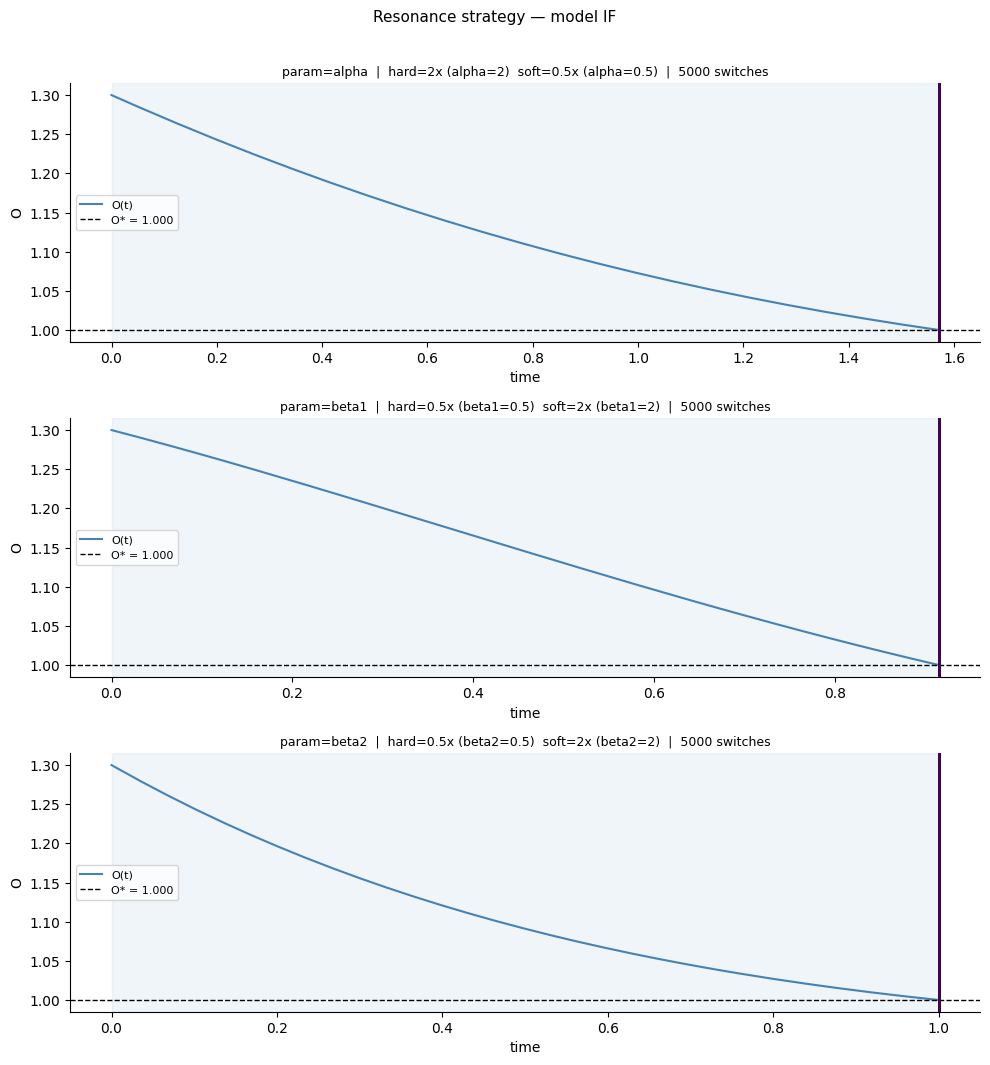

In [69]:
rs = run_resonance_demo(model_if)

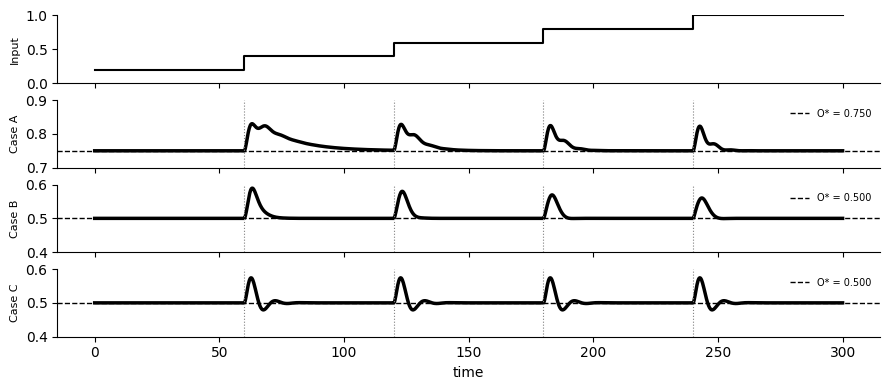

In [70]:
# ── Models a, b, c — stepped input, starting from SS at Input=0.2 ─────────────
input_vals = [0.2, 0.4, 0.6, 0.8, 1.0]
dt         = 60
t_seg      = np.linspace(0, dt, 300)

def stepped_trajectory(model, input_vals, dt, t_seg, y0=None):
    """Single continuous trajectory with piecewise-constant Input steps."""
    if y0 is None:
        y0 = np.ones(len(model.state_vars)) * 0.5
    y_cur, t_offset = y0.copy(), 0.0
    t_all, O_all = [], []
    for inp in input_vals:
        sol = solve_ivp(model.get_f({'Input': inp}), (0, dt), y_cur,
                        t_eval=t_seg, method='Radau', rtol=1e-8, atol=1e-10)
        t_all.append(sol.t + t_offset)
        O_all.append(sol.y[model.output_idx])
        y_cur     = sol.y[:, -1]
        t_offset += dt
    return np.concatenate(t_all), np.concatenate(O_all)

def eval_ss(model, input_val):
    """Evaluate the symbolic steady state at a given Input value."""
    subs = {sym: model.params_base[name]
            for name, sym in zip(model._param_names, model._sym_params)}
    subs[model._sym_input] = input_val
    return np.array([float(model._ss_dict[s].subs(subs)) for s in model._sym_state])

t_stairs = np.repeat(np.arange(len(input_vals) + 1) * dt, 2)[1:-1]
i_stairs = np.repeat(input_vals, 2)
t_vlines = np.arange(1, len(input_vals)) * dt
x_ticks  = np.arange(0, len(input_vals) * dt + 1, 50)

models_abc = [model_a, model_b, model_c]
ylims_abc  = [(0.7, 0.9), (0.4, 0.6), (0.4, 0.6)]
n = len(models_abc)

fig, axes = plt.subplots(n + 1, 1, figsize=(9, (n + 1) * 1.0), sharex=True)

axes[0].plot(t_stairs, i_stairs, color='k', lw=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Input', fontsize=8)
axes[0].tick_params(labelbottom=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (model, ylim) in enumerate(zip(models_abc, ylims_abc)):
    ax = axes[i + 1]

    y_ss_02 = eval_ss(model, 0.2)
    O_star  = float(y_ss_02[model.output_idx])

    t_cat, O_cat = stepped_trajectory(model, input_vals, dt, t_seg, y0=y_ss_02)

    ax.plot(t_cat, O_cat, color='k', lw=2.5)
    ax.axhline(O_star, color='k', ls='--', lw=1, label=f'O* = {O_star:.3f}')
    for t_v in t_vlines:
        ax.axvline(t_v, color='grey', ls=':', lw=0.8)
    ax.set_ylim(*ylim)
    ax.set_ylabel(f'Case {model.name.upper()}', fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('time')
axes[-1].set_xticks(x_ticks)
plt.tight_layout(h_pad=0.2)
plt.show()

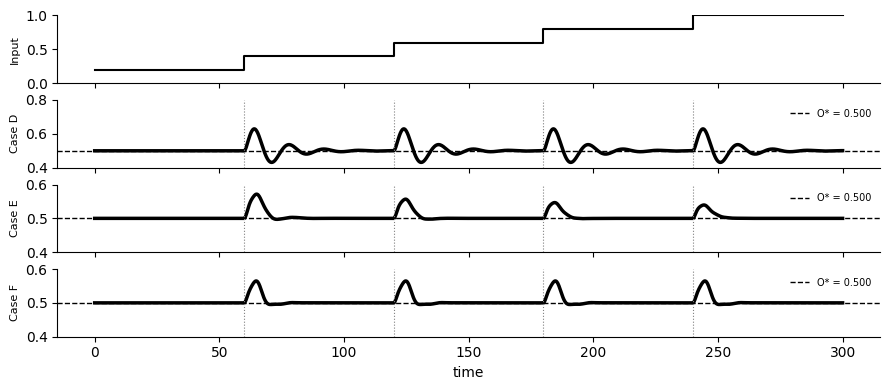

In [71]:
# ── Models d, e, f — stepped input, starting from SS at Input=0.2 ─────────────
models_def = [model_d, model_e, model_f]
ylims_def  = [(0.4, 0.8), (0.4, 0.6), (0.4, 0.6)]
n = len(models_def)

fig, axes = plt.subplots(n + 1, 1, figsize=(9, (n + 1) * 1.0), sharex=True)

axes[0].plot(t_stairs, i_stairs, color='k', lw=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Input', fontsize=8)
axes[0].tick_params(labelbottom=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (model, ylim) in enumerate(zip(models_def, ylims_def)):
    ax = axes[i + 1]

    y_ss_02 = eval_ss(model, 0.2)
    O_star  = float(y_ss_02[model.output_idx])

    t_cat, O_cat = stepped_trajectory(model, input_vals, dt, t_seg, y0=y_ss_02)

    ax.plot(t_cat, O_cat, color='k', lw=2.5)
    ax.axhline(O_star, color='k', ls='--', lw=1, label=f'O* = {O_star:.3f}')
    for t_v in t_vlines:
        ax.axvline(t_v, color='grey', ls=':', lw=0.8)
    ax.set_ylim(*ylim)
    ax.set_ylabel(f'Case {model.name.upper()}', fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('time')
axes[-1].set_xticks(x_ticks)
plt.tight_layout(h_pad=0.2)
plt.show()